# Briefsummary Parser

Our high throughput dft code returns text files with a summary of calculation results. Here we convert this text files to a pandas dataframe containing all the information

We use some tools developed for this propose alone. The module `Featurizer` parses the strings in the `briefsummary.dat` files and recreates information of each sample as magnetic configuration, lattice occupation signatures, etc.

# TODO: calculate formation energies and put them in the df !

In [1]:
from Tools.DatasetTools.Commoms import *
#sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
dataset = 'Fe-Mo' # 'Cr-Co-W',  'Fe-Mo'

# Load Brief Summary

In [46]:
BS = StructSummaryParser(dataset, ForceMakeBS=True).BriefSummary

need to create briefsummary list
creating new list of briefsummaries


In [47]:
BS[BS.index.str.contains('R')]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Mo_sv,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Fe_pv,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482


In [48]:
BS[BS.index.str.contains('R-AAAAAAAABBB.NM')]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,bulk R-AAAAAAAABBB,11.758856 A,-8.881292,276.280981 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,39,14,53,0.735849,0.264151,0.081659,0.029249,-0.028935


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [22]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

In [23]:
Features  = Featurizer(BS)

In [24]:
if 'Fe' in dataset:
    ground_states = Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [25]:
ground_states

{('Fe_pv', 'FM', 'bcc'): -8.255294,
 ('Fe_pv', 'NM', 'hcp'): -8.184069,
 ('Fe_pv', 'NM', 'fcc'): -8.104999,
 ('Mo_sv', 'FM', 'bcc'): -10.934251,
 ('Mo_sv', 'NM', 'bcc'): -10.934283}

I want to see how different the machine learning part can be if the ground state for the non magnetic part is taken as the hcp or the fcc.

In [26]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'hcp')]
if 'Mo' in dataset:
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [27]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'fcc')]
if 'Mo' in dataset:
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [28]:
this_ground_states

{('Fe_pv', 'FM'): -8.255294,
 ('Fe_pv', 'NM'): -8.184069,
 ('Mo_sv', 'FM'): -10.934251,
 ('Mo_sv', 'NM'): -10.934283}

In [29]:
BS['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv', 'FM', 'bcc')]})

In [30]:
BS['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)

In [31]:
BS['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

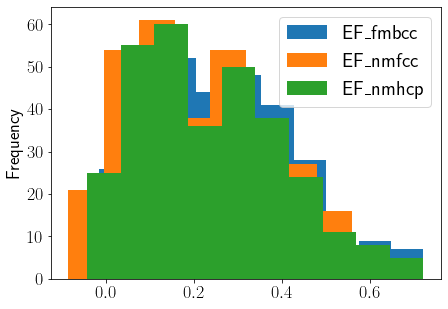

In [32]:
fig, ax =  plt.subplots()
for target_case in ['EF_fmbcc', 'EF_nmfcc', 'EF_nmhcp']:
    ax = BS[target_case].plot.hist(ax=ax, label = target_case)
ax.legend()

In [33]:
#BS.to_pickle(f'{dataset}/ParsedBriefsummary.pkl')

# Magnetic vs Non Magnetic

In [ ]:
target_case = 'EF_nmhcp'

In [ ]:
EFFM = BS[target_case][Features.Mag == 'FM']

In [ ]:
EFNM = BS['EF_nmhcp'][Features.Mag == 'NM']

In [ ]:
EFFM.index = EFFM.index.str.replace('.FM', '')

In [ ]:
EFNM.index = EFNM.index.str.replace('.NM', '')

In [ ]:
BS[target_case][Features.StrucNames == 'fcc']

In [ ]:
BS[target_case][Features.StrucNames == 'bcc']

In [ ]:
BS[target_case][Features.StrucNames == 'hcp']

In [ ]:
DE_mag  = EFNM - EFFM 

In [ ]:
DE_mag[ abs(DE_mag > 0.1)]

In [ ]:
DE_mag[DE_mag < 0 ]

# some graphs for Raw 

In [ ]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [ ]:
Features.StrucNames

In [ ]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    BS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=BS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [ ]:
def do_mag(tag):
    if tag:
        return 'FM'
    else:
        return 'NM'

In [ ]:
BS['Mag'] = BS.index.str.contains('FM')

In [ ]:
BS['Mag'] = BS['Mag'].map(do_mag)

In [ ]:
BS['Mag']

In [ ]:
BS['Phase'] = Target_Class

In [ ]:
BS = BS[~BS.index.str.contains('delta')]

In [ ]:
fig, ax = plt.subplots(figsize=(12,10))
sns.histplot(y=BS['Phase'], ax=ax, hue = BS['Mag'], multiple='stack', palette=['mediumseagreen', 'darkblue'], binwidth=0.1)
stack_histogram_file_name = os.path.join(dataset, 'graphs', f'{dataset}_StackCounts_RAW.pdf')
fig.tight_layout()
fig.savefig(stack_histogram_file_name)